In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score, KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

Lampiran Link Pengumpulan tugas:

- Streamlit: https://deployplacement-salaryutsmd-npbelwso2tkx4zg57tkizp.streamlit.app/
- Github repo: https://github.com/AlvinWjy25/deploy_Placement-Salary_UTS_MD
- Video Drive: https://drive.google.com/drive/folders/1GPH1CqPjq5wP6LVFZe6dT87GNy7mpKnk?usp=sharing

### **1. Explaratory Data Analysis & Workflow**

In [2]:
BASE_DIR = os.getcwd() 
df = pd.read_csv(os.path.join(BASE_DIR, "data", "raw", "B.csv"), low_memory=False)

In [3]:
df.head(5)

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [4]:
df.describe()

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

Dataset berisi kolom fitur informasi kuliah mahasiswa yang dapat dipakai untuk prediksi klasifikasi (placement_status) dan regresi (salary_package_lpa)
- student id: ID Unik siswa
- gender: Jenis kelamin
- ssc_percentage: Persentase nilai sekolah menengah (kelas 10)
- hsc_percentage: Persentase nilai sekolah menengah atas (kelas 12)
- degree_percentage: Persentase nilai selama menempuh gelar sarjana
- cgpa: Indeks Prestasi Kumulatif (IPK) terakhir
- entrance_exam_score: Skor ujian masuk perguruan tinggi/perusahaan
- technical_skill_score: Skor kemampuan teknis sesuai bidang
- soft_skill_score: Skor kemampuan interpersonal dan komunikasi
- internship_count: Jumlah program magang yang pernah diikuti
- live_projects: Jumlah proyek nyata/industri yang dikerjakan
- work_experience_months: Durasi pengalaman kerja profesional dalam bulan
- certifications: Jumlah sertifikasi profesional yang dimiliki
- attendance_percentage: Persentase kehadiran selama perkuliahan
- backlogs: Jumlah mata kuliah yang sempat tidak lulus
- extracurricular_activities (Partisipasi dalam kegiatan organisasi/UKM (Yes/No))
- placement_status: Status penempatan kerja (1: Placed, 0: Not Placed)
- salary_package_lpa: Estimasi gaji per tahun dalam satuan Lakhs Per Annum

#### **1.1 Check Categorical Anomally**

In [6]:
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
cat_cols

['gender', 'extracurricular_activities']

In [7]:
for col in cat_cols:
    display(df[col].value_counts().to_frame().T)

gender,Male,Female
count,2504,2496


extracurricular_activities,No,Yes
count,2553,2447


#### **1.2 Check Numeric Anomally**

In [8]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
num_cols

['student_id',
 'ssc_percentage',
 'hsc_percentage',
 'degree_percentage',
 'cgpa',
 'entrance_exam_score',
 'technical_skill_score',
 'soft_skill_score',
 'internship_count',
 'live_projects',
 'work_experience_months',
 'certifications',
 'attendance_percentage',
 'backlogs',
 'placement_status',
 'salary_package_lpa']

In [9]:
display(df.isna().sum().to_frame().T)

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [10]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns

#### **1.3 Check for Duplicates**

In [11]:
df.duplicated().sum()

np.int64(0)

Kesimpulan: Dataset ini cukup bersih dari null value, duplicate, column anomally, dan siap untuk di proses lebih lanjut.

### **2. Plotting**


In [12]:
df["placement_status"].value_counts()

placement_status
0    4134
1     866
Name: count, dtype: int64

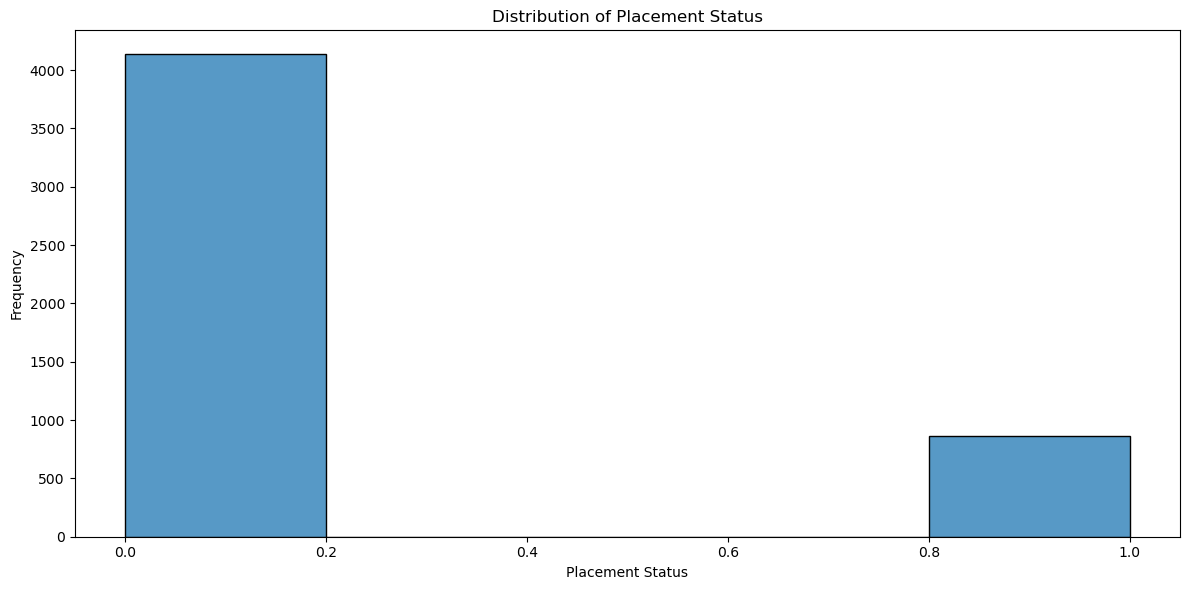

In [13]:
plt.figure(figsize = (12, 6))
sns.histplot(df["placement_status"], bins = 5, kde=False)
plt.title("Distribution of Placement Status")
plt.xlabel("Placement Status")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


Berdasarkan distribusi target placement_status untuk klasifikasi, memiliki data imbalance ekstrim.

- Terlihat perbedaan frekuensi yang sangat kontras antara kelas 0 (Tidak Ditempatkan, > 4000 sampel) dan kelas 1 (Ditempatkan, < 1000 sampel). 

- Model mungkin menghasilkan akurasi yang sangat bagus karena hanya menebak kelas mayoritas 0, namun gagal mengidentifikasi kandidat yang sebenarnya berpotensi mendapatkan pekerjaan.

Diperlukan adanya penanganan tuning pada model agar tidak asal tebak not placed (0).

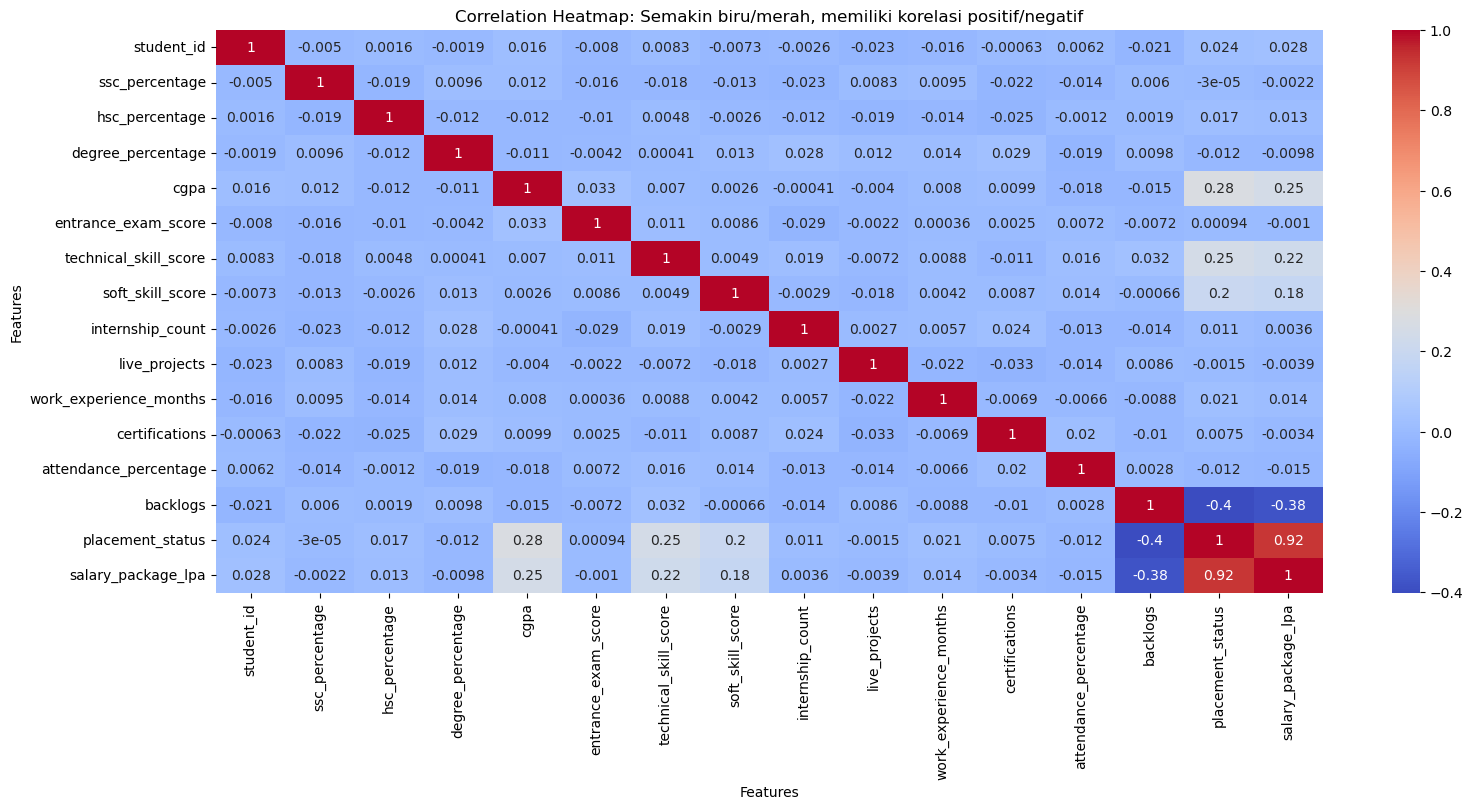

In [14]:
plt.figure(figsize=(16, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap: Semakin biru/merah, memiliki korelasi positif/negatif")
plt.tight_layout()
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()



Dapat dilihat disini, bahwa kolom fitur backlogs memiliki korelasi yang sangat tinggi dengan kedua kolom target (placement_status & salary_package).

**Backlogs** secara teknis adalah istilah yang merujuk pada *mata kuliah yang gagal diselesaikan / tidak lulus* pada percobaan pertama.

**Alasan**: Nilai yang belum memenuhi standar minimal, Attendance yang belum cukup, Tidak mengikuti ujian, Beban Administratif yang belum selesai, dsb

In [15]:
display(df.groupby("backlogs")["placement_status"].mean().to_frame().T)

backlogs,0,1,2,3,4,5
placement_status,0.34229,0.342569,0.369779,0.0,0.0,0.0


Pada tabel pengelompokan ini, Backlogs 0, 1, dan 2 pada dataset menunjukan Mahasiswa masih memiliki peluang kerja (34.2% -36.9%). Jika backlogs lebih dari 2, maka peluang mendapatkan pekerjaan langsung 0. Dataset menunjukan bahwa ada aturan eliminasi absolut saat backlogs > 2. 

Uniknya, mahasiswa dengan backlogs = 2 memiliki peluang mendapatkan kerja sedikit lebih besar dibanding 0 dan 1.

In [16]:
display(df.groupby("backlogs")["salary_package_lpa"].mean().to_frame().T)

backlogs,0,1,2,3,4,5
salary_package_lpa,3.233797,3.237909,3.243759,0.0,0.0,0.0


In [18]:
df_filtered = df[df['backlogs'] <= 2]
df_filtered.shape

(2464, 18)

Tabel pengelompokan ini mengkonfirmasi info sebelumnya dimana orang yang backlogs > 2 langsung tidak memiliki pekerjaan => tidak punya gaji. Uniknya juga, individu dengan backlogs 2 memiliki gaji yang sedikit lebih besar secara rata-rata dibanding orang yang backlogs 0 dan 1.

**Penanganan**: Backlogs harus di drop, meski kita secara teknis bisa membuat backlog ini di FE-weighted (mengkombinasikan fitur lain dengan backlogs agar bebannya tidak terlalu besar), backlog sendiri merupakan langkah untuk model melihat masa depan jika kita melihat perspektif dataset ini. Oleh karena itu, kita akan buang backlogs, walau secara teknis di dataset lain, karakteristik backlogs mungkin bukan dead giveaway terhadap outcome target.

---------------------------------------------------------------------------------------------------------------------------------------------------------------------
Pada heatmap ini juga, banyak fitur fitur yang sebenarnya memiliki korelasi yang cukup rendah dengan status placement (hanya biru muda, atau merah muda ~ kurang dari 0.1), ini dapat membuat model berpotensi kesulitan mengidentifikasi fitur apa yang paling membantu prediksi target ketika backlogs sudah di drop.

**Solusi**: Fitur Engineering dengan mengkombinasikan beberapa fitur yang membantu model memahami pergerakan korelasi fitur terhadap target.

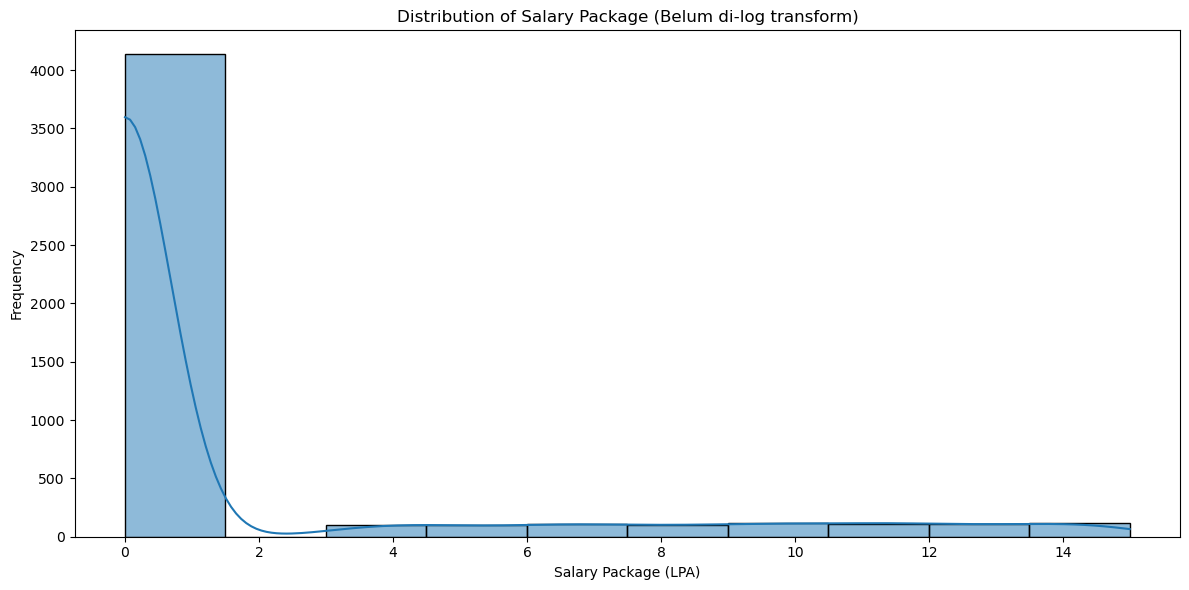

In [19]:
plt.figure(figsize=(12, 6))
sns.histplot(df["salary_package_lpa"], bins=10, kde=True)
plt.title("Distribution of Salary Package (Belum di-log transform)")
plt.xlabel("Salary Package (LPA)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

Pada kolom target LPA, meski angka terlihat kecil, dapat dilihat adanya kesenjangan besar dari 0 hingga ~1.8 dimana dataset didominasi oleh orang yang memiliki LPA kecil. Dan orang yang memiliki gaji LPA > 2 memiliki distribusi data yang lebih flat. Ini dapat membuat model regresi kesulitan mengenali pola LPA.

Distribusi data: *Right-Skewed*.

**Solusi**: 
- log-transform salary package (LPA) untuk membuat distribusi data lebih terlihat polanya. 
- Karena data juga sebelumnya didominasi oleh orang yang belum placed (0), maka untuk prediksi regresi kita hanya akan menggunakan data yang placed(1). Jika data tetap digabung dengan orang yang not placed dengan placed, maka model akan mengalami distorsi karena mencoba mempelajari pola gaji dari individu yang sebenarnya tidak memiliki gaji.

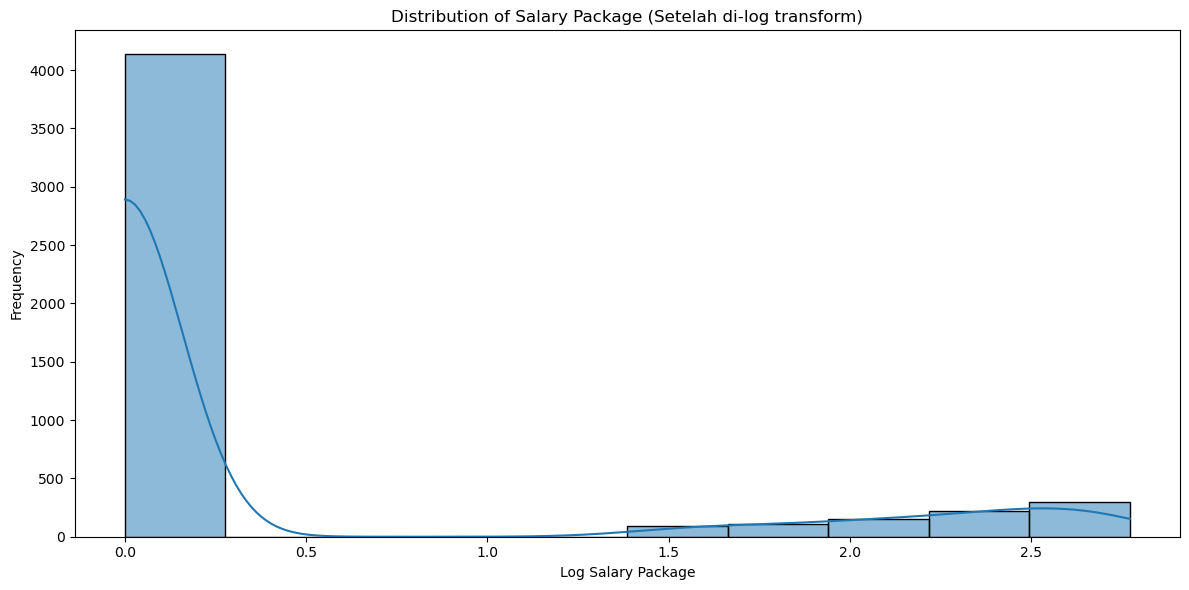

In [20]:
df_temp = df.copy()
df_temp["salary_log"] = np.log1p(df_temp["salary_package_lpa"])

plt.figure(figsize=(12, 6))
sns.histplot(df_temp["salary_log"], bins=10, kde=True)
plt.title("Distribution of Salary Package (Setelah di-log transform)")
plt.xlabel("Log Salary Package")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### **3. Feature Enginering**

In [21]:
df = pd.read_csv(os.path.join(BASE_DIR, 'data','raw', 'B.csv'), low_memory=False)

df['skill_combined'] = df["technical_skill_score"] + df["soft_skill_score"]
df['skill_ratio'] = df["technical_skill_score"] / (df["soft_skill_score"] + 1)
df['cgpa_skill'] = df['cgpa'] * df['technical_skill_score']

df['academic_avg'] = (
    df['ssc_percentage'] + df['hsc_percentage'] + df['degree_percentage']
) / 3

df['academic_consistency'] = df[['ssc_percentage','hsc_percentage','degree_percentage']].std(axis=1)
# df['backlog_flag'] = (df['backlogs'] > 2).astype(int)

Kita akan membuat 2 dataframe:
- df_final_class: dataframe yang contain seluruh orang yang not placed (0) dengan placed(1) berserta fitur FEnya
- df_final_reg: dataframe yang hanya contain seluruh orang yang placed(1) berserta FEnya

In [22]:
target = ["placement_status", "salary_package_lpa"]

exclude_cols = ["student_id",  "hsc_percentage", "ssc_percentage", "degree_percentage",
                 "internship_count", "live_projects", "work_experience_months", "backlogs"] 
#drop kolom lama untuk reduce multicolinearity

features = [col for col in df.columns if col not in exclude_cols]

df_final_class = df[features]
df_final_reg = df_final_class[df_final_class['placement_status'] > 0]

In [23]:
df_final_class.columns

Index(['gender', 'cgpa', 'entrance_exam_score', 'technical_skill_score',
       'soft_skill_score', 'certifications', 'attendance_percentage',
       'extracurricular_activities', 'placement_status', 'salary_package_lpa',
       'skill_combined', 'skill_ratio', 'cgpa_skill', 'academic_avg',
       'academic_consistency'],
      dtype='object')

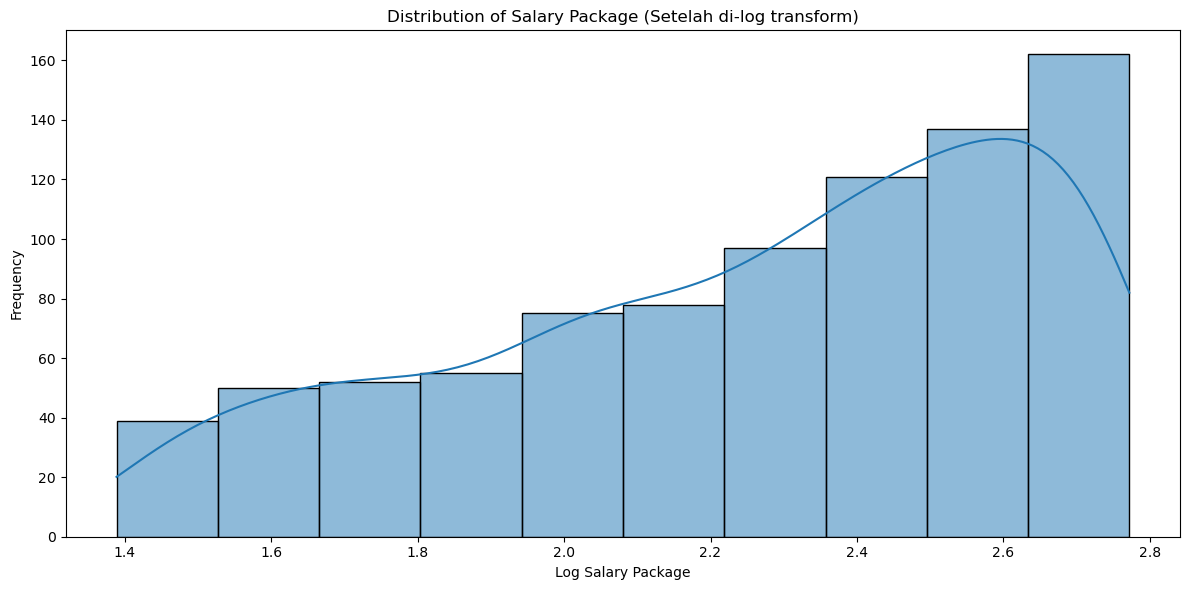

In [24]:
plt.figure(figsize=(12, 6))
sns.histplot(np.log1p(df_final_reg[target[1]]), bins=10, kde=True)
plt.title("Distribution of Salary Package (Setelah di-log transform)")
plt.xlabel("Log Salary Package")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

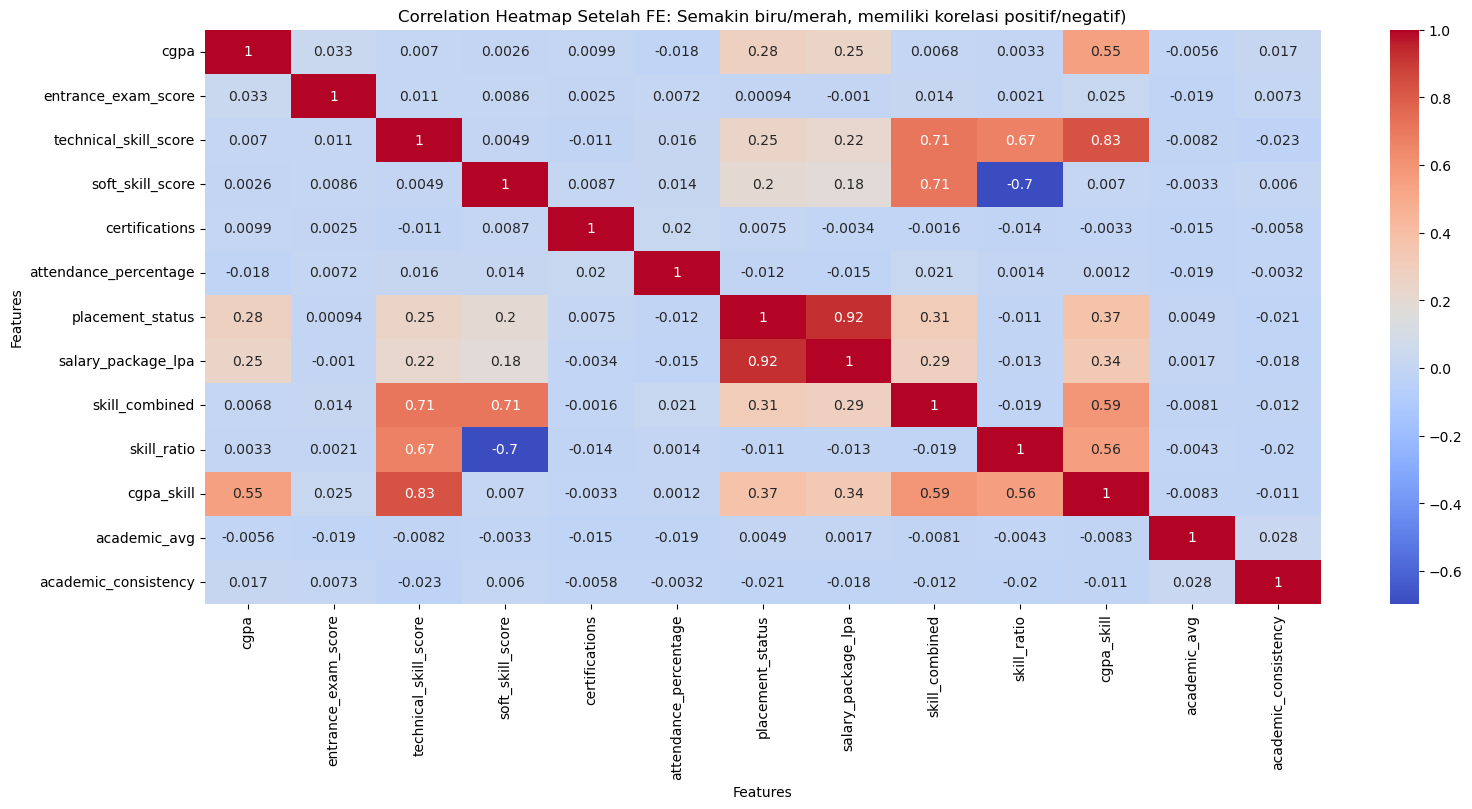

In [25]:
num_cols = df_final_class[features].select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(16, 8))
sns.heatmap(df_final_class[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap Setelah FE: Semakin biru/merah, memiliki korelasi positif/negatif)")
plt.tight_layout()
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()



Dengan membuat kolom-kolom baru (FE):
    1. skill_combined, skill_ratio, cgpa_skill   : Membantu memahami pengaruh skill soft, teknikal, dan edukasi yang biasanya diinginkan oleh ketenagakerjaan.
    2. academic_avg, academic_consistency        : Membantu memahami tingkat edukasi mahasiswa, semakin konsisten & bagus, semakin baik peluang masuk ke ketenagakerjaan.
    3. 

Kita membantu model memahami korelasi antar kolom dengan outcome(target).

### 4. **Building Pipeline & Transformer**

#### **4.1 Basic Function**

##### **4.1.1 Update Preprocessor Modular**

In [26]:
def update_preprocessor(X, features): #memudahkan setup preprocessor saat klasifikasi dan regresi tanpa perlu scroll
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["object"]).columns
    feature_custom = features.copy()

    for t in target: #mencari dan delete target didalam feature_custom
        if t in feature_custom:
            feature_custom.remove(t)
        
    preprocessor = ColumnTransformer(
      transformers=[
          ('num', StandardScaler(), num_cols),
          ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
        ],
        remainder = 'drop'
    )
    return preprocessor

In [27]:
df[cat_cols].describe()

,gender,extracurricular_activities
count,5000,5000
unique,2,2
top,Male,No
freq,2504,2553


- memakai standardscaler untuk menangani perbedaan skala:
    - CGPA: 0 ~ 10
    - Scores Percentages: 0 ~ 100
    - Work Experience: bulanan
    - Intership/Project: 0 ~ 10
    Tanpa scaling, beberapa model akan menilai Scores percentages lebih besar bobotnya, padahal CGPA dan pengalaman bekerja berpotensi memiliki bobot yang lebih tinggi

- memakai onehotencoder karena kolom memiliki kardinalitas rendah dan tidak ada urutan kepentingan (sangat puas ~ sangat tidak puas)

##### **4.1.2 Evaluate CV Score**

Kita akan menggunakan StratifiedKFold untuk klasifikasi dan KFold untuk regresi dalam mengukur kinerja model secara lebih akurat dan mencegah overfitting dengan membagi dataset menjadi K bagian yang sama besar lalu dilatih dan diuji berulang sebanyak K-kali.

In [28]:
def evaluate_class_cv(model, X, y, cv_folds = 5):
    skf = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
    accuracy_scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy')
    precision_scores = cross_val_score(model, X, y, cv=skf, scoring='precision')
    recall_scores = cross_val_score(model, X, y, cv=skf, scoring='recall')
    f1_macro = cross_val_score(model, X, y, cv=skf, scoring='f1_macro')
    f1_weighted = cross_val_score(model, X, y, cv=skf, scoring='f1_weighted')

    print(f"Cross-Validated Accuracy: {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")
    print(f"Cross-Validated Precision: {precision_scores.mean():.4f} ± {precision_scores.std():.4f}")
    print(f"Cross-Validated Recall: {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")
    print(f"Cross-Validated F1-macro: {f1_macro.mean():.4f} ± {f1_macro.std():.4f}")
    print(f"Cross-Validated F1-weighted: {f1_weighted.mean():.4f} ± {f1_weighted.std():.4f}")

    return accuracy_scores.mean(), precision_scores.mean(), recall_scores.mean(), f1_macro.mean(),f1_weighted.mean()

In [29]:
def smape_calculate(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred))
    ) * 100

In [30]:
def evaluate_reg_cv(model, X, y_log, cv_folds = 5):

    kf = KFold(n_splits=cv_folds, shuffle=True, random_state=42)

    r2_list = []
    mae_list = []
    mse_list = []
    rmse_list = []
    mape_list = []
    smape_list = []
    
    for train_idx, val_idx in kf.split(X):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_log, y_val_log = y_log.iloc[train_idx], y_log.iloc[val_idx]

        model.fit(X_train, y_train_log)

        y_pred_log = model.predict(X_val)

        y_pred = np.expm1(y_pred_log)
        y_val = np.expm1(y_val_log)

        mask = y_val > 0

        y_val_safe = y_val[mask]
        y_pred_safe = y_pred[mask]

        r2 = r2_score(y_val, y_pred)
        mae = mean_absolute_error(y_val, y_pred)
        mse = mean_squared_error(y_val, y_pred)
        rmse = np.sqrt(mse)
        mape = np.mean(np.abs((y_val_safe - y_pred_safe) / y_val_safe)) * 100
        smape = smape_calculate(y_val, y_pred)

        r2_list.append(r2)
        mae_list.append(mae)
        mse_list.append(mse)
        rmse_list.append(rmse)
        mape_list.append(mape)
        smape_list.append(smape)
    
    print(f"R^2: {np.mean(r2_list):.4f} ± {np.std(mae_list):.4f}")
    print(f"MAE: {np.mean(mae_list):.4f} ± {np.std(mae_list):.4f}")
    print(f"MSE: {np.mean(mse_list):.4f} ± {np.std(mse_list):.4f}")
    print(f"RMSE: {np.mean(rmse_list):.4f} ± {np.std(rmse_list):.4f}")        
    print(f"MAPE: {np.mean(mape_list):.4f}% ± {np.std(mape_list):.4f}")
    print(f"SMAPE: {np.mean(smape_list):.4f}% ± {np.std(smape_list):.4f}")

    return (
        np.mean(r2_list),
        np.mean(mae_list),
        np.mean(mse_list),
        np.mean(rmse_list),
        np.mean(mape_list),
        np.mean(smape_list)
    )

#### **4.2 Classification (placement_status)**

In [31]:
X = df_final_class.drop(columns = target)
y = df_final_class[target[0]]

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
        X, y, test_size=0.2, random_state=42
)

unified_model_rfc = Pipeline([
    ('preprocessor', update_preprocessor(X_train_1, X_train_1.columns.tolist())),
    ('classifier', RandomForestClassifier(random_state=42, n_jobs = 6))
])

unified_model_xgb = Pipeline([
    ('preprocessor', update_preprocessor(X_train_1, X_train_1.columns.tolist())),
    ('classifier', XGBClassifier(random_state=42, n_jobs = 6))
])

unified_model_lgbm = Pipeline([
    ('preprocessor', update_preprocessor(X_train_1, X_train_1.columns.tolist())),
    ('classifier', LGBMClassifier(random_state=42, n_jobs = 6, verbose = -1))
])

# print(f"Kelas unik di data: {np.unique(y_test_1)}")
# print(f"Jumlah kelas: {len(np.unique(y_test_1))}")
# print(f"Kolom training: {X_train_1.columns.tolist()}")

In [32]:
X_train_1.columns

Index(['gender', 'cgpa', 'entrance_exam_score', 'technical_skill_score',
       'soft_skill_score', 'certifications', 'attendance_percentage',
       'extracurricular_activities', 'skill_combined', 'skill_ratio',
       'cgpa_skill', 'academic_avg', 'academic_consistency'],
      dtype='object')

In [33]:
X_train_1.dtypes

gender                         object
cgpa                          float64
entrance_exam_score             int64
technical_skill_score           int64
soft_skill_score                int64
certifications                  int64
attendance_percentage           int64
extracurricular_activities     object
skill_combined                  int64
skill_ratio                   float64
cgpa_skill                    float64
academic_avg                  float64
academic_consistency          float64
dtype: object

In [34]:
def review_classification(y_test_class, y_pred_class):
    print(f"Classification: \n{classification_report(y_test_class, y_pred_class)}\n")
    print(f"Confusion matrix: \n{confusion_matrix(y_test_class, y_pred_class)}\n")
    print(f"*" * 55)

##### **4.2.1 Random Forest Classification** -> (BASELINE)

In [35]:
unified_model_rfc.fit(X_train_1, y_train_1)
y_pred = unified_model_rfc.predict(X_test_1)

review_classification(y_test_1, y_pred)
accuracy, precision, recall, f1_macro, f1_weight = evaluate_class_cv(unified_model_rfc, X_train_1, y_train_1)

Classification: 
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       801
           1       0.56      0.47      0.51       199

    accuracy                           0.82      1000
   macro avg       0.72      0.69      0.70      1000
weighted avg       0.81      0.82      0.82      1000


Confusion matrix: 
[[727  74]
 [105  94]]

*******************************************************
Cross-Validated Accuracy: 0.8370 ± 0.0138
Cross-Validated Precision: 0.5154 ± 0.0534
Cross-Validated Recall: 0.4004 ± 0.0364
Cross-Validated F1-macro: 0.6774 ± 0.0255
Cross-Validated F1-weighted: 0.8286 ± 0.0141


Summary dari Baseline RFC:
 - Model lemah pada precision dan recall meski akurasinya 0.835 dengan std yang stabil (tidak overfit). 
 - Precision pada kelas 1 adalah 0.56 yang benar-benar mendapat pekerjaan padahal aslinya tidak (false positive)
- Recall rendah,dari 199 orang yang sebenarnya mendapatkan pekerjaan, model hanya berhasil mendeteksi 94 orang saja. Sisanya (105 orang) terlewat (False Negative) untuk mengenali potensi sukses mahasiswa.

Priority: Increase overall precision dan recall dengan tuning f1-macro.

F1-macro mampu melatih model untuk jangan sampai ada kandidat potensial yang terlewat dan memastikan model memberikan perhatian yang setara pada kelas minoritas (placed), mencegah bias terhadap kelas mayoritas.

In [36]:
feature_importances = unified_model_rfc.named_steps['classifier'].feature_importances_
feature_names = unified_model_rfc.named_steps['preprocessor'].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
0,num__cgpa,0.161571
8,num__cgpa_skill,0.145214
3,num__soft_skill_score,0.107195
2,num__technical_skill_score,0.104828
7,num__skill_ratio,0.097693
6,num__skill_combined,0.090588
10,num__academic_consistency,0.063676
9,num__academic_avg,0.061500
1,num__entrance_exam_score,0.058077
5,num__attendance_percentage,0.051243


In [37]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__class_weight':[None, 'balanced', 'balanced_subsample']
}

grid_search = GridSearchCV(
    unified_model_rfc,
    param_grid,
    cv = 5,
    scoring="f1_macro",
    n_jobs = 6,
    verbose = 1
)

grid_search.fit(X_train_1, y_train_1)

best_model_rfc = grid_search.best_estimator_
y_pred_tuned = best_model_rfc.predict(X_test_1)

review_classification(y_test_1, y_pred_tuned)
print(f"Parameter Terbaik: {grid_search.best_params_}")
print(f"Skor Terbaik: {grid_search.best_score_}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Classification: 
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       801
           1       0.53      0.94      0.67       199

    accuracy                           0.82      1000
   macro avg       0.75      0.86      0.77      1000
weighted avg       0.89      0.82      0.83      1000


Confusion matrix: 
[[632 169]
 [ 12 187]]

*******************************************************
Parameter Terbaik: {'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Skor Terbaik: 0.7744176898406309


In [38]:
best_model_rfc.fit(X_train_1, y_train_1)
y_pred_final = best_model_rfc.predict(X_test_1)

review_classification(y_test_1, y_pred_final)
best_accuracy_rfc, best_precision_rfc, best_recall_rfc, best_f1_macro_rfc, best_f1_weighted_rfc = evaluate_class_cv(best_model_rfc, X_train_1, y_train_1)

Classification: 
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       801
           1       0.53      0.94      0.67       199

    accuracy                           0.82      1000
   macro avg       0.75      0.86      0.77      1000
weighted avg       0.89      0.82      0.83      1000


Confusion matrix: 
[[632 169]
 [ 12 187]]

*******************************************************
Cross-Validated Accuracy: 0.8355 ± 0.0088
Cross-Validated Precision: 0.5040 ± 0.0133
Cross-Validated Recall: 0.9505 ± 0.0220
Cross-Validated F1-macro: 0.7751 ± 0.0086
Cross-Validated F1-weighted: 0.8527 ± 0.0073


In [39]:
df_temp_compare = pd.DataFrame({
    'y_true': y_test_1,
    'y_pred': y_pred_final
}).reset_index(drop=True)

display(df_temp_compare.head(10))

,y_true,y_pred
0,0,0
1,0,0
2,0,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,1
8,0,0
9,0,0


##### **4.2.2 XGBoost Classification**

In [40]:
unified_model_xgb.fit(X_train_1, y_train_1)
y_pred = unified_model_xgb.predict(X_test_1)

review_classification(y_test_1, y_pred)
accuracy, precision, recall, f1_macro, f1_weight = evaluate_class_cv(unified_model_xgb, X_train_1, y_train_1)

Classification: 
              precision    recall  f1-score   support

           0       0.88      0.90      0.89       801
           1       0.56      0.51      0.53       199

    accuracy                           0.82      1000
   macro avg       0.72      0.70      0.71      1000
weighted avg       0.82      0.82      0.82      1000


Confusion matrix: 
[[721  80]
 [ 98 101]]

*******************************************************
Cross-Validated Accuracy: 0.8337 ± 0.0144
Cross-Validated Precision: 0.5010 ± 0.0469
Cross-Validated Recall: 0.4529 ± 0.0561
Cross-Validated F1-macro: 0.6882 ± 0.0294
Cross-Validated F1-weighted: 0.8302 ± 0.0155


In [41]:
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__learning_rate': [0.1, 0.05],
    'classifier__max_depth': [3, 5, 7],
    'classifier__scale_pos_weight': [4],
    'classifier__tree_method': ['hist']
}

grid_search = GridSearchCV(
    unified_model_xgb,
    param_grid_xgb,
    cv = 5,
    scoring="f1_macro",
    n_jobs = 6,
    verbose = 1
)

grid_search.fit(X_train_1, y_train_1)

best_model_xgb = grid_search.best_estimator_
y_pred_tuned = best_model_xgb.predict(X_test_1)

review_classification(y_test_1, y_pred_tuned)
print(f"Parameter Terbaik: {grid_search.best_params_}")
print(f"Skor Terbaik: {grid_search.best_score_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Classification: 
              precision    recall  f1-score   support

           0       1.00      0.78      0.88       801
           1       0.53      1.00      0.70       199

    accuracy                           0.83      1000
   macro avg       0.77      0.89      0.79      1000
weighted avg       0.91      0.83      0.84      1000


Confusion matrix: 
[[628 173]
 [  0 199]]

*******************************************************
Parameter Terbaik: {'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__scale_pos_weight': 4, 'classifier__tree_method': 'hist'}
Skor Terbaik: 0.77710481900237


In [42]:
best_model_xgb.fit(X_train_1, y_train_1)
y_pred_final = best_model_xgb.predict(X_test_1)

review_classification(y_test_1, y_pred_final)
best_accuracy_xgb, best_precision_xgb, best_recall_xgb, best_f1_macro_xgb, best_f1_weighted_xgb = evaluate_class_cv(best_model_xgb, X_train_1, y_train_1)

Classification: 
              precision    recall  f1-score   support

           0       1.00      0.78      0.88       801
           1       0.53      1.00      0.70       199

    accuracy                           0.83      1000
   macro avg       0.77      0.89      0.79      1000
weighted avg       0.91      0.83      0.84      1000


Confusion matrix: 
[[628 173]
 [  0 199]]

*******************************************************
Cross-Validated Accuracy: 0.8330 ± 0.0102
Cross-Validated Precision: 0.5001 ± 0.0147
Cross-Validated Recall: 0.9985 ± 0.0030
Cross-Validated F1-macro: 0.7774 ± 0.0104
Cross-Validated F1-weighted: 0.8515 ± 0.0086


##### **4.2.3 LightGBM Classification**

In [43]:
import warnings
warnings.filterwarnings("ignore")

unified_model_lgbm.fit(X_train_1, y_train_1)
y_pred = unified_model_lgbm.predict(X_test_1)

review_classification(y_test_1, y_pred)
accuracy, precision, recall, f1_macro, f1_weight = evaluate_class_cv(unified_model_lgbm, X_train_1, y_train_1)

Classification: 
              precision    recall  f1-score   support

           0       0.87      0.89      0.88       801
           1       0.52      0.48      0.50       199

    accuracy                           0.81      1000
   macro avg       0.70      0.69      0.69      1000
weighted avg       0.80      0.81      0.81      1000


Confusion matrix: 
[[712  89]
 [103  96]]

*******************************************************
Cross-Validated Accuracy: 0.8370 ± 0.0120
Cross-Validated Precision: 0.5119 ± 0.0356
Cross-Validated Recall: 0.4889 ± 0.0483
Cross-Validated F1-macro: 0.7011 ± 0.0228
Cross-Validated F1-weighted: 0.8354 ± 0.0123


In [44]:
param_grid_lgbm = {
    'classifier__is_unbalance': [True], 
    'classifier__num_leaves': [31, 50],         
    'classifier__max_depth': [-1, 10, 20],      
    'classifier__learning_rate': [0.1, 0.05],
    'classifier__n_estimators': [100, 200],
    'classifier__min_child_samples': [20, 30], 
    'classifier__subsample': [0.8, 1.0],
    'classifier__tree_method': ['hist']
}

grid_search_lgbm = GridSearchCV(
    unified_model_lgbm,
    param_grid_lgbm,
    cv = 5,
    scoring="precision",
    n_jobs = 6,
    verbose = 1
)

grid_search_lgbm.fit(X_train_1, y_train_1)

best_model_lgbm = grid_search_lgbm.best_estimator_
y_pred_tuned = best_model_lgbm.predict(X_test_1)

review_classification(y_test_1, y_pred_tuned)
print(f"Parameter Terbaik: {grid_search_lgbm.best_params_}")
print(f"Skor Terbaik: {grid_search_lgbm.best_score_}")

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Classification: 
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       801
           1       0.56      0.61      0.58       199

    accuracy                           0.83      1000
   macro avg       0.73      0.74      0.74      1000
weighted avg       0.83      0.83      0.83      1000


Confusion matrix: 
[[705  96]
 [ 78 121]]

*******************************************************
Parameter Terbaik: {'classifier__is_unbalance': True, 'classifier__learning_rate': 0.1, 'classifier__max_depth': -1, 'classifier__min_child_samples': 20, 'classifier__n_estimators': 200, 'classifier__num_leaves': 50, 'classifier__subsample': 0.8, 'classifier__tree_method': 'hist'}
Skor Terbaik: 0.5185350797952424


In [45]:
best_model_lgbm.fit(X_train_1, y_train_1)
y_pred_final = best_model_lgbm.predict(X_test_1)

review_classification(y_test_1, y_pred_final)
best_accuracy_lgbm, best_precision_lgbm, best_recall_lgbm, best_f1_macro_lgbm, best_f1_weighted_lgbm = evaluate_class_cv(best_model_lgbm, X_train_1, y_train_1)

Classification: 
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       801
           1       0.56      0.61      0.58       199

    accuracy                           0.83      1000
   macro avg       0.73      0.74      0.74      1000
weighted avg       0.83      0.83      0.83      1000


Confusion matrix: 
[[705  96]
 [ 78 121]]

*******************************************************
Cross-Validated Accuracy: 0.8375 ± 0.0172
Cross-Validated Precision: 0.5115 ± 0.0403
Cross-Validated Recall: 0.6164 ± 0.0575
Cross-Validated F1-macro: 0.7293 ± 0.0269
Cross-Validated F1-weighted: 0.8433 ± 0.0161


#### **4.3 Summary Classification**

In [46]:
display(f"Column used: {df_final_class.columns.tolist()}")

"Column used: ['gender', 'cgpa', 'entrance_exam_score', 'technical_skill_score', 'soft_skill_score', 'certifications', 'attendance_percentage', 'extracurricular_activities', 'placement_status', 'salary_package_lpa', 'skill_combined', 'skill_ratio', 'cgpa_skill', 'academic_avg', 'academic_consistency']"

In [47]:
summary = pd.DataFrame({
    'Best Model': ['Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy (CV)': [best_accuracy_rfc, best_accuracy_xgb, best_accuracy_lgbm],
    'Precision (CV)': [best_precision_rfc, best_precision_xgb, best_precision_lgbm],
    'Recall (CV)': [best_recall_rfc, best_recall_xgb, best_recall_lgbm],
    'F1-macro (CV)': [best_f1_macro_rfc, best_f1_macro_xgb, best_f1_macro_lgbm],
    'F1-weighted (CV)': [best_f1_weighted_rfc, best_f1_weighted_xgb, best_f1_weighted_lgbm]
})

display(summary.sort_values(by='F1-macro (CV)', ascending=False))

,Best Model,Accuracy (CV),Precision (CV),Recall (CV),F1-macro (CV),F1-weighted (CV)
1,XGBoost,0.8330,0.500083,0.998507,0.777449,0.851536
0,Random Forest,0.8355,0.504047,0.950533,0.775074,0.852748
2,LightGBM,0.8375,0.511482,0.616395,0.729346,0.843325


- Recall 0.99: Model hampir tidak pernah melewatkan mahasiswa yang "Placed". Hampir semua orang yang aslinya dapat kerja, berhasil ditebak "Placed" oleh model.
- Precision 0.5: Model terlalu optimis, dari 100 orang yang ditebak placed (1), hanya 50 orang aslinya yang benar-benar dapat kerja. 50 lainnya yang sebenarnya tidak placed (0) tapi salah ditebak sukses (False Positive)

Priority: F1-macro
"jangan sampai ada kandidat potensial yang terlewat". Nilai F1-macro pada XGB Classifier (0.777) menunjukkan keseimbangan terbaik dalam mengenali kedua kelas secara adil.

#### **4.4 Regression**

In [48]:
df["placement_status"].value_counts()

placement_status
0    4134
1     866
Name: count, dtype: int64

In [49]:
X = df_final_reg.drop(columns = target)
y = np.log1p(df_final_reg[target[1]])

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

unified_model_rfr = Pipeline([
    ('preprocessor', update_preprocessor(X_train_2, features)),
    ('regressor', RandomForestRegressor(random_state=42, n_jobs = 6))
])

unified_model_xgbr = Pipeline([
    ('preprocessor', update_preprocessor(X_train_2, features)),
    ('regressor', XGBRegressor(random_state=42, n_jobs = 6))
])

unified_model_lgbmr = Pipeline([
    ('preprocessor', update_preprocessor(X_train_2, features)),
    ('regressor', LGBMRegressor(random_state=42, n_jobs = 6, verbose = -1))
])


In [50]:
X_train_2.columns

Index(['gender', 'cgpa', 'entrance_exam_score', 'technical_skill_score',
       'soft_skill_score', 'certifications', 'attendance_percentage',
       'extracurricular_activities', 'skill_combined', 'skill_ratio',
       'cgpa_skill', 'academic_avg', 'academic_consistency'],
      dtype='object')

##### **4.4.1 Random Forest Regressor** -> (BASELINE)

In [51]:
#(model, X, y, cv_folds = 5):
unified_model_rfr.fit(X_train_2, y_train_2)
y_pred_rfr = unified_model_rfr.predict(X_test_2)

y_pred_rfr_norm = np.expm1(y_pred_rfr)
y_test_2_norm = np.expm1(y_test_2)

r2, mae, mse, rmse, mape, smape = evaluate_reg_cv(unified_model_rfr, X_train_2, y_train_2)

R^2: -0.1409 ± 0.0603
MAE: 3.1499 ± 0.0603
MSE: 13.6593 ± 0.5933
RMSE: 3.6950 ± 0.0809
MAPE: 42.1788% ± 2.0337
SMAPE: 36.5841% ± 0.6420


- R2 negatif menunjukan model lebih buruk daripada model yang hanya main tebak di rata-rata saat memprediksi nilai asli. Hal ini terjadi karena variansi tinggi yang ada di pola data meski sudah di skala log saat training.
- MAE, RMSE menunjukan bahwa model tidak terlalu banyak menghasilkan outlier error yang sangat besar (~3 LPA)
- SMAPE 36.58% mengatakan rata-rata kesalahan prediksi model adalah sekitar ~36% dibanding nilai asli. Rentang ini cukup lebar untuk memprediksi gaji yang idealnya dibawah 20%.

Priority: Targetkan SMAPE sebagai metrik penilaian utama prediksi Salary

In [61]:
param_grid_rfr = {
    'regressor__n_estimators': [100, 200],
    'regressor__max_depth': [5, 10, None],     # Batasi kedalaman untuk mencegah R^2 negatif
    'regressor__min_samples_leaf': [2, 5],      # Sangat krusial untuk generalisasi gaji
}

grid_search_rfr = GridSearchCV(
    unified_model_rfr,
    param_grid_rfr,
    cv = 5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs = 6,
    verbose = 1
)

grid_search_rfr.fit(X_train_2, y_train_2)
best_model_rfr = grid_search_rfr.best_estimator_

print(f"Parameter Terbaik: {grid_search_rfr.best_params_}")
print(f"Skor Terbaik: {grid_search_rfr.best_score_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Parameter Terbaik: {'regressor__max_depth': 5, 'regressor__min_samples_leaf': 2, 'regressor__n_estimators': 200}
Skor Terbaik: -0.15903686105240694


In [53]:
best_model_rfr.fit(X_train_2, y_train_2)
y_pred_final = best_model_rfr.predict(X_test_2)

y_pred_final_exp = np.expm1(y_pred_final)
y_test_2_exp = np.expm1(y_test_2)

rfr_r2, rfr_mae, rfr_mse, rfr_rmse, rfr_mape, rfr_smape = evaluate_reg_cv(best_model_rfr, X_train_2, y_train_2)

R^2: -0.0776 ± 0.0635
MAE: 3.0886 ± 0.0635
MSE: 12.9033 ± 0.5306
RMSE: 3.5914 ± 0.0742
MAPE: 41.6997% ± 2.2522
SMAPE: 35.8598% ± 0.7034


##### **4.4.2 XGBoost Regressor**

In [54]:
unified_model_xgbr.fit(X_train_2, y_train_2)
y_pred_xgbr = unified_model_xgbr.predict(X_test_2)

y_pred_xgbr_exp = np.expm1(y_pred_xgbr)
y_test_2_exp = np.expm1(y_test_2)

r2, mae, mse, rmse ,mape, smape = evaluate_reg_cv(unified_model_xgbr, X_train_2, y_train_2)

R^2: -0.4116 ± 0.0728
MAE: 3.4329 ± 0.0728
MSE: 16.9131 ± 0.9192
RMSE: 4.1110 ± 0.1124
MAPE: 47.1058% ± 2.3280
SMAPE: 39.6653% ± 0.8283


In [55]:
param_grid_xgbr = {
    'regressor__n_estimators': [100, 200],
    'regressor__learning_rate': [0.05, 0.01], # Lebih kecil lebih aman untuk data sedikit
    'regressor__max_depth': [3, 5],            # Jangan terlalu dalam agar tidak menghafal noise gaji
    'regressor__subsample': [0.8],             # Bagging untuk stabilitas
    'regressor__objective': ['reg:squarederror']
}

grid_search_xgbr = GridSearchCV(
    unified_model_xgbr,
    param_grid_xgbr,
    cv = 5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs = -1,
    verbose = 1
)

grid_search_xgbr.fit(X_train_2, y_train_2)
best_model_xgbr = grid_search_xgbr.best_estimator_

print(f"Parameter Terbaik: {grid_search_xgbr.best_params_}")
print(f"Skor Terbaik: {grid_search_xgbr.best_score_}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Parameter Terbaik: {'regressor__learning_rate': 0.01, 'regressor__max_depth': 3, 'regressor__n_estimators': 100, 'regressor__objective': 'reg:squarederror', 'regressor__subsample': 0.8}
Skor Terbaik: -0.15765314873506947


In [56]:
best_model_xgbr.fit(X_train_2, y_train_2)
y_pred_final = best_model_xgbr.predict(X_test_2)

y_pred_final_exp = np.expm1(y_pred_final)
y_test_2_exp = np.expm1(y_test_2)

xgbr_r2, xgbr_mae, xgbr_mse, xgbr_rmse, xgbr_mape, xgbr_smape = evaluate_reg_cv(best_model_xgbr, X_train_2, y_train_2)

R^2: -0.0602 ± 0.0770
MAE: 3.0763 ± 0.0770
MSE: 12.7014 ± 0.5362
RMSE: 3.5631 ± 0.0754
MAPE: 41.5195% ± 2.5338
SMAPE: 35.7018% ± 0.9467


##### **4.4.3 LightGBM Regressor**

In [57]:
unified_model_lgbmr.fit(X_train_2, y_train_2)
y_pred_lgbmr = unified_model_lgbmr.predict(X_test_2)

y_pred_lgbmr_exp = np.expm1(y_pred_lgbmr)
y_test_2_exp = np.expm1(y_test_2)

r2, mae, mse, rmse, mape, smape = evaluate_reg_cv(unified_model_lgbmr, X_train_2, y_train_2)

R^2: -0.3382 ± 0.1182
MAE: 3.3246 ± 0.1182
MSE: 16.0249 ± 1.1566
RMSE: 4.0006 ± 0.1429
MAPE: 45.7507% ± 3.1365
SMAPE: 38.5302% ± 1.3550


In [58]:
param_grid_lgbmr = {
    'regressor__num_leaves': [20, 31],         # Lebih kecil dari default (31) bagus untuk data N=866
    'regressor__learning_rate': [0.05, 0.01],
    'regressor__n_estimators': [100, 200],
    'regressor__min_child_samples': [10, 20],  # Melindungi model dari noise data gaji
    'regressor__importance_type': ['gain']     # Agar feature importance lebih intuitif
}

grid_search_lgbmr = GridSearchCV(
    unified_model_lgbmr,
    param_grid_lgbmr,
    cv = 5,
    scoring="neg_mean_absolute_percentage_error",
    n_jobs = -1,
    verbose = 1
)

grid_search_lgbmr.fit(X_train_2, y_train_2)
best_model_lgbmr = grid_search_lgbmr.best_estimator_

print(f"Parameter Terbaik: {grid_search_lgbmr.best_params_}")
print(f"Skor Terbaik: {grid_search_lgbmr.best_score_}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Parameter Terbaik: {'regressor__importance_type': 'gain', 'regressor__learning_rate': 0.01, 'regressor__min_child_samples': 10, 'regressor__n_estimators': 100, 'regressor__num_leaves': 20}
Skor Terbaik: -0.15919823607318112


In [59]:
best_model_lgbmr.fit(X_train_2, y_train_2)
y_pred_final = best_model_lgbmr.predict(X_test_2)

y_pred_final_exp = np.expm1(y_pred_final)
y_test_2_exp = np.expm1(y_test_2)

lgbmr_r2, lgbmr_mae, lgbmr_mse, lgbmr_rmse, lgbmr_mape, lgbmr_smape = evaluate_reg_cv(best_model_lgbmr, X_train_2, y_train_2)

R^2: -0.0980 ± 0.0756
MAE: 3.1022 ± 0.0756
MSE: 13.1502 ± 0.6082
RMSE: 3.6253 ± 0.0842
MAPE: 41.9330% ± 2.2791
SMAPE: 35.9989% ± 0.7201


#### **4.5 Summary Regression**

In [60]:
summary_regression = pd.DataFrame({
    'Best Model': ['Random Forest Regressor', 'XGBoost Regressor', 'LightGBM Regressor'],
    'R^2 (CV)': [rfr_r2, xgbr_r2, lgbmr_r2],
    'MAE (CV)': [rfr_mae, xgbr_mae, lgbmr_mae],
    'MSE (CV)': [rfr_mse, xgbr_mse, lgbmr_mse],
    'RMSE (CV)': [rfr_rmse, xgbr_rmse, lgbmr_rmse],
    'MAPE (CV)': [rfr_mape, xgbr_mape, lgbmr_mape],
    'SMAPE (CV)': [rfr_smape, xgbr_smape, lgbmr_smape],
})

display(summary.sort_values(by=['F1-macro (CV)'], ascending=False))
summary_regression.sort_values(by='SMAPE (CV)', ascending=True)

,Best Model,Accuracy (CV),Precision (CV),Recall (CV),F1-macro (CV),F1-weighted (CV)
1,XGBoost,0.8330,0.500083,0.998507,0.777449,0.851536
0,Random Forest,0.8355,0.504047,0.950533,0.775074,0.852748
2,LightGBM,0.8375,0.511482,0.616395,0.729346,0.843325


,Best Model,R^2 (CV),MAE (CV),MSE (CV),RMSE (CV),MAPE (CV),SMAPE (CV)
1,XGBoost Regressor,-0.060153,3.076283,12.701426,3.563108,41.519488,35.701758
0,Random Forest Regressor,-0.077626,3.088637,12.903346,3.591355,41.699664,35.859790
2,LightGBM Regressor,-0.097979,3.102152,13.150230,3.625346,41.933047,35.998895


Decision:
- Target: placement_status (Classification) - XGBoostClassifier
- Target: Salary           (Regression)     - XGBoostRegressor